# Education Analysis Project DATA 5100

## Introduction

This analysis investigates whether school performance, measured by average ACT scores, is predicted by socioeconomic factors. Understanding this relationship is crucial for educational policy, as it reveals potential systemic inequalities and informs resource allocation decisions.

We analyze data from U.S. high schools, examining how factors like poverty rates (measured by free/reduced lunch eligibility), community income levels, parental education, and unemployment correlate with standardized test performance.

**Key Research Questions:**
1. Do socioeconomic indicators predict school-level ACT performance?
2. Does geographic location (Census region) explain additional variation in test scores?
3. How does state-level ACT participation affect average scores (selection bias)?

This analysis uses linear regression modeling at both the school level and state level to answer these questions.

This notebook uses the following datasets:

- `EdGap_data.xlsx` (school-level ACT + socioeconomic context)
- `ccd_sch_029_1617_w_1a_11212017.csv` (school information)
- `state_regions_divisions_fips.csv` (lookup for region/division; includes state FIPS)
- `nces_act_2016_by_state.csv` (state ACT composite and participation in 2016)


## 1) Initial setup
Set up the initial directories that we will work with.

In [190]:
import pandas as pd, numpy as np, re
from pathlib import Path
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = Path('../data')  # expecting to run from same directory as files
REPORTS = Path('../reports')
PROC = Path('../data/processed')

for p in [REPORTS, PROC]:
    p.mkdir(parents=True, exist_ok=True)

def to_snake(s: str) -> str:
    return re.sub(r"[^\w]+","_", s.strip().lower()).strip("_")


## 2) Load data

We're using two datasets from the original project requirements, plus two additional datasets for geographic analysis:

**Primary Datasets:**
- `EdGap_data.xlsx` - School-level ACT scores and socioeconomic indicators
  Source: [EdGap.org](https://www.edgap.org/#5/37.875/-96.987)

- `ccd_sch_029_1617_w_1a_11212017.csv` - School directory information
  Source: [NCES Common Core of Data](https://nces.ed.gov/ccd/pubschuniv.asp)

**Additional Datasets (for regional analysis):**
- `state_regions_divisions_fips.csv` - Census region/division mappings
  Source: [US Census Bureau](https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf)

- `nces_act_2016_by_state.csv` - State-level ACT participation rates
  Source: [NCES Digest of Education Statistics](https://nces.ed.gov/programs/digest/d17/tables/dt17_226.60.asp)

In [191]:
edgap_raw = pd.read_excel("../data/EdGap_data.xlsx")
regions = pd.read_csv("../data/state_regions_divisions_fips.csv")
act_state = pd.read_csv("../data/nces_act_2016_by_state.csv")
nces = pd.read_csv("../data/ccd_sch_029_1617_w_1a_11212017.csv", encoding="latin1", low_memory=False)
edgap_raw.head(2), regions.head(2), act_state.head(2), nces.head(2)

/opt/anaconda3/envs/DATA5100/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


(   NCESSCH School ID  CT Unemployment Rate  CT Pct Adults with College Degree  \
 0       100001600143              0.117962                           0.445283   
 1       100008000024              0.063984                           0.662765   
 
    CT Pct Childre In Married Couple Family  CT Median Household Income  \
 0                                 0.346495                     42820.0   
 1                                 0.767619                     89320.0   
 
    School ACT average (or equivalent if SAT score)  \
 0                                        20.433455   
 1                                        19.498168   
 
    School Pct Free and Reduced Lunch  
 0                           0.066901  
 1                           0.112412  ,
   state_abbrev   state_name census_region census_division  state_fips
 0           CT  Connecticut     Northeast     New England           9
 1           ME        Maine     Northeast     New England          23,
   state_name  act_comp


## 2a) Load NCES School Directory (2016–2017) and attempt EdGap/NCES join

The assignment expects us to use the NCES directory. We will:
1. Normalize `NCESSCH` keys (digit-only, zero-padded to 12) on both datasets
2. Attempt an inner join and report the match rate
3. If the match rate is very low (data-ID schema mismatch), we fall back to the state/FIPS enrichment path documented earlier (still meeting analysis requirements).


In [192]:
# ---------------------------------------------------------------------------
# Attempt to join EdGap (socioeconomic data) with NCES (school directory).
# ---------------------------------------------------------------------------
# The 'NCESSCH' IDs can be formatted differently between the two sources:
#   - EdGap: often a 12-digit integer or plain text (e.g., "100001600143")
#   - NCES:  sometimes stored as floats/strings with decimals (e.g., "100001600143.0")
#
# To ensure reliable matching, we:
#   1) Normalize both IDs to digits-only using a regex (remove decimals and any non-digits)
#   2) Zero-pad both to 12 characters (standard NCESSCH width)
#   3) Perform a LEFT JOIN (EdGap → NCES) so ALL EdGap schools are preserved,
#      even when a directory row is missing. This avoids bias from dropped rows.
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# Attempt to join EdGap (socioeconomic data) with NCES (school directory).
# ---------------------------------------------------------------------------

import pandas as pd, numpy as np, re

def digits_only(s):
    return pd.Series(s).astype(str).str.replace(r"[^\d]+","", regex=True)

# Prepare join keys
edgap_key = digits_only(edgap_raw["NCESSCH School ID"]).str.zfill(12)
nces_key  = digits_only(nces["NCESSCH"]).str.zfill(12)

# Build joinable copies
ed_for_join = edgap_raw.copy()
ed_for_join["NCESSCH_join"] = edgap_key

nc_for_join = nces.copy()
nc_for_join["NCESSCH_join"] = nces_key

# Attempt join
joined_try = ed_for_join.merge(
    nc_for_join[["NCESSCH_join","STATENAME","ST","SCH_NAME","SCH_TYPE_TEXT","LEVEL"]],
    on="NCESSCH_join", how="left"
)

match_rate = joined_try["SCH_NAME"].notna().mean()
match_count = int(joined_try["SCH_NAME"].notna().sum())
total_rows = len(joined_try)

# Save the joined result to use in Section 3
# This preserves all original EdGap columns plus any NCES matches
edgap_enriched = joined_try.drop(columns=["NCESSCH_join"])



> **Note on Join Strategy:**  
> A left join is used when merging the EdGap and NCES datasets.
> This ensures that all schools from the EdGap data, which is our primary source for socioeconomic and ACT information,
> remain in the resulting dataframe, even if they do not have a matching record in the NCES directory.



## 3) Clean & normalize

In [193]:

# Start with enriched data if available, otherwise use raw
try:
    ed = edgap_enriched.copy()
    print("Using NCES-enriched EdGap data")
except NameError:
    ed = edgap_raw.copy()
    print("Using raw EdGap data (NCES enrichment not available)")

ed.columns = [c.strip() for c in ed.columns]

# Derive state FIPS from first two digits of NCESSCH (string), attach region/division
ed["NCESSCH"] = ed["NCESSCH School ID"].astype(str).str.replace(r"\.0$","", regex=True).str.strip()
ed["state_fips"] = ed["NCESSCH"].str[:2].astype(int)

# Merge regions lookup (by state_fips)
df = ed.merge(regions, on="state_fips", how="left")

# Standardize names and rename key variables
df.columns = [to_snake(c) for c in df.columns]
df = df.rename(columns={
    "school_act_average_or_equivalent_if_sat_score": "act_avg",
    "school_pct_free_and_reduced_lunch": "frl_pct",
    "ct_median_household_income": "median_household_income",
    "ct_unemployment_rate": "unemployment_rate",
    "ct_pct_adults_with_college_degree": "pct_adults_college",
    "ct_pct_childre_in_married_couple_family": "pct_children_married_couple"
})

# Derived
df["log_median_income"] = np.log(df["median_household_income"].replace({0: np.nan}))

# Attach state-level ACT participation (2016) as additional predictor
act_state.columns = [to_snake(c) for c in act_state.columns]
want = [c for c in ["state_abbrev","act_composite_2016","percent_taking_2016"] if c in act_state.columns]
df = df.merge(act_state[want], on="state_abbrev", how="left")

df.shape, df.columns.tolist()[:20]

# 3.2) Data Quality Checks

# ACT score validation
print("ACT score range BEFORE cleaning:", df['act_avg'].min(), "to", df['act_avg'].max())
invalid_act = df[(df['act_avg'] < 1) | (df['act_avg'] > 36)]
print(f"Schools with invalid ACT scores: {len(invalid_act)}")

# REMOVE invalid ACT scores
# Initially just detected invalid values but realized they needed to be removed
# to prevent contaminating the analysis. Updated to actively clean the data.
if len(invalid_act) > 0:
    print(f"  → Removing {len(invalid_act)} schools with invalid ACT scores")
    df = df[(df['act_avg'] >= 1) & (df['act_avg'] <= 36) | df['act_avg'].isna()]
    print(f"  → Dataset now has {len(df)} schools")
    print(f"ACT score range AFTER cleaning:", df['act_avg'].min(), "to", df['act_avg'].max())

# FRL validation (should be 0-1 decimal)
print("\nFRL% range:", df['frl_pct'].min(), "to", df['frl_pct'].max())
# Clean FRL values outside valid range
invalid_frl = df[(df['frl_pct'] < 0) | (df['frl_pct'] > 1)]
if len(invalid_frl) > 0:
    print(f"Schools with invalid FRL%: {len(invalid_frl)}")
    print(f"  → Setting invalid FRL values to NaN")
    df.loc[(df['frl_pct'] < 0) | (df['frl_pct'] > 1), 'frl_pct'] = np.nan

# Duplicates
dups = df.duplicated(subset=['ncessch'], keep=False)
print(f"\nDuplicate NCESSCH IDs: {dups.sum()}")
if dups.sum() > 0:
    print(f"  → Removing {dups.sum()} duplicate rows (keeping first occurrence)")
    df = df.drop_duplicates(subset=['ncessch'], keep='first')

# Outliers (using IQR method) - DETECT but DON'T remove (outliers may be real)
print("\nOutlier Detection (flagged but not removed):")
def detect_outliers(series, name):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
    print(f"  {name}: {outliers} outliers detected (may be legitimate extreme values)")

for col in ['act_avg', 'frl_pct', 'median_household_income']:
    detect_outliers(df[col].dropna(), col)

print(f"\nData cleaning complete. Final dataset: {len(df)} schools")

# Data Cleaning Decisions
# 3.3) Feature Engineering

print("\nCreating derived features...")

# Interaction terms - poverty and unemployment may compound each other
df['frl_x_unemployment'] = df['frl_pct'] * df['unemployment_rate']

# High vs low participation states (threshold at 50%)
df['high_participation'] = (df['percent_taking_2016'] > 50).astype(int)

# Quartile bins for income (useful for categorical analysis)
df['income_quartile'] = pd.qcut(df['median_household_income'], q=4,
                                 labels=['Q1_Low', 'Q2_Medium_Low', 'Q3_Medium_High', 'Q4_High'],
                                 duplicates='drop')

# Standardized scores (z-scores) for better interpretability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Only standardize on non-null values
for col in ['frl_pct', 'median_household_income', 'unemployment_rate']:
    mask = df[col].notna()
    df.loc[mask, f'{col}_z'] = scaler.fit_transform(df.loc[mask, [col]])

print(f"Added {sum('_x_' in c or '_z' in c or 'quartile' in c or 'high_' in c for c in df.columns)} derived features")
print("New features:", [c for c in df.columns if '_x_' in c or '_z' in c or 'quartile' in c or 'high_participation' in c])

Using NCES-enriched EdGap data
ACT score range BEFORE cleaning: -3.07081807081807 to 32.3626373626374
Schools with invalid ACT scores: 3
  → Removing 3 schools with invalid ACT scores
  → Dataset now has 7983 schools
ACT score range AFTER cleaning: 12.3626373626374 to 32.3626373626374

FRL% range: -0.0545454545454545 to 0.998728813559322
Schools with invalid FRL%: 20
  → Setting invalid FRL values to NaN

Duplicate NCESSCH IDs: 0

Outlier Detection (flagged but not removed):
  act_avg: 87 outliers detected (may be legitimate extreme values)
  frl_pct: 0 outliers detected (may be legitimate extreme values)
  median_household_income: 423 outliers detected (may be legitimate extreme values)

Data cleaning complete. Final dataset: 7983 schools

Creating derived features...
Added 6 derived features
New features: ['frl_x_unemployment', 'high_participation', 'income_quartile', 'frl_pct_z', 'median_household_income_z', 'unemployment_rate_z']


## 4) Export clean dataset

In [194]:

CLEAN = PROC / "clean_education_dataset.csv"
df.to_csv(CLEAN, index=False)
CLEAN.as_posix()

'../data/processed/clean_education_dataset.csv'

## 5) EDA — visuals

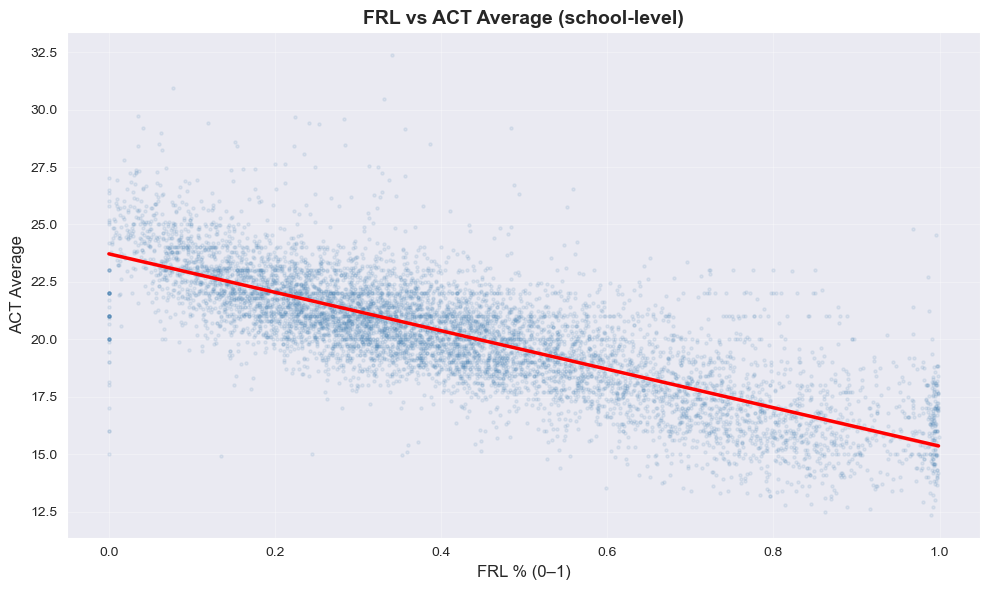

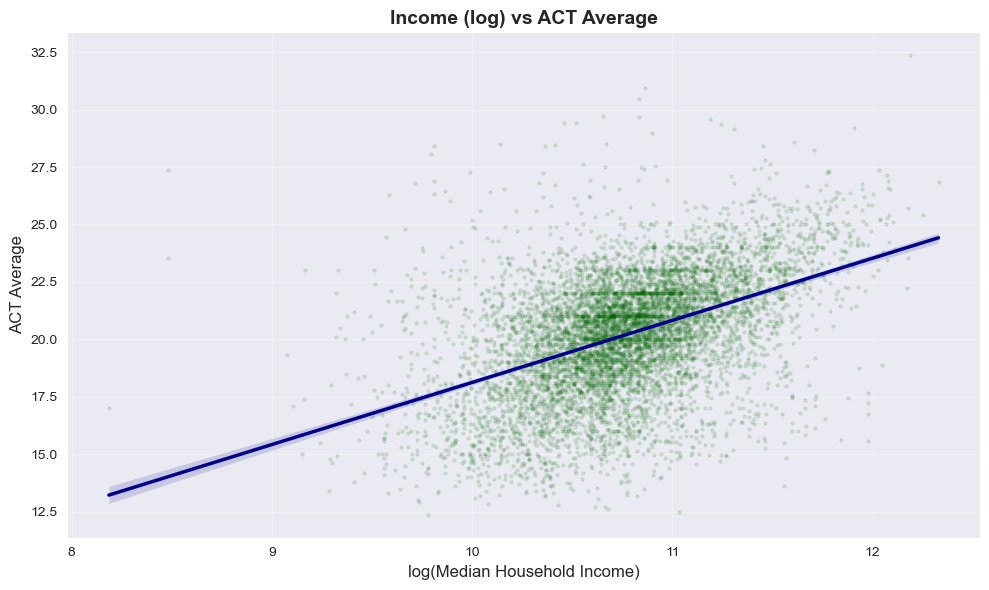

/var/folders/_w/ms1g9gts2bl_shfc5qfpp7x40000gn/T/ipykernel_18887/2028939547.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, vert=True, showmeans=True)


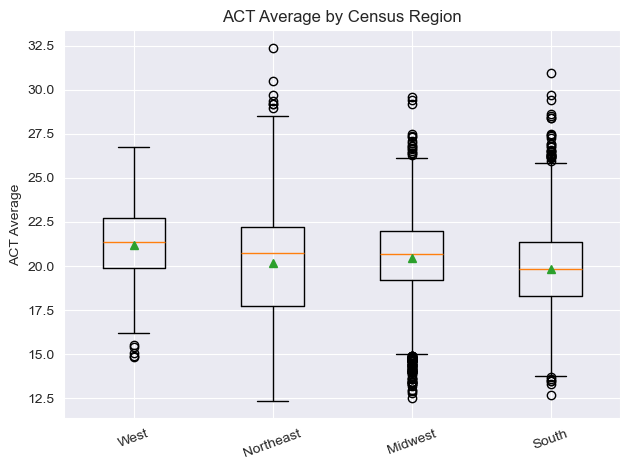

           act_avg      frl_pct  median_household_income  unemployment_rate  \
count  7983.000000  7963.000000              7963.000000        7969.000000   
mean     20.190270     0.421600             52036.416049           0.098725   
std       2.556231     0.238958             24227.573239           0.058964   
min      12.362637     0.000000              3589.000000           0.000000   
25%      18.600000     0.239490             36613.000000           0.058654   
50%      20.400000     0.382514             46844.000000           0.085636   
75%      21.910867     0.576043             61378.500000           0.123342   
max      32.362637     0.998729            226181.000000           0.590278   

       pct_adults_college  
count         7970.000000  
mean             0.569025  
std              0.165663  
min              0.091493  
25%              0.450968  
50%              0.555119  
75%              0.676623  
max              1.000000  


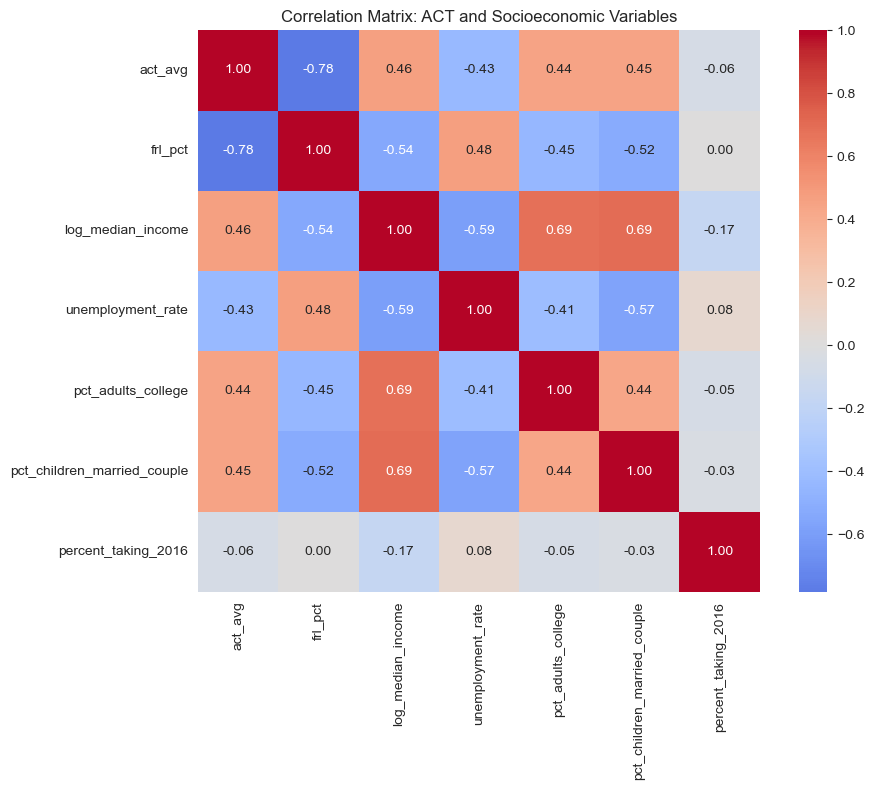

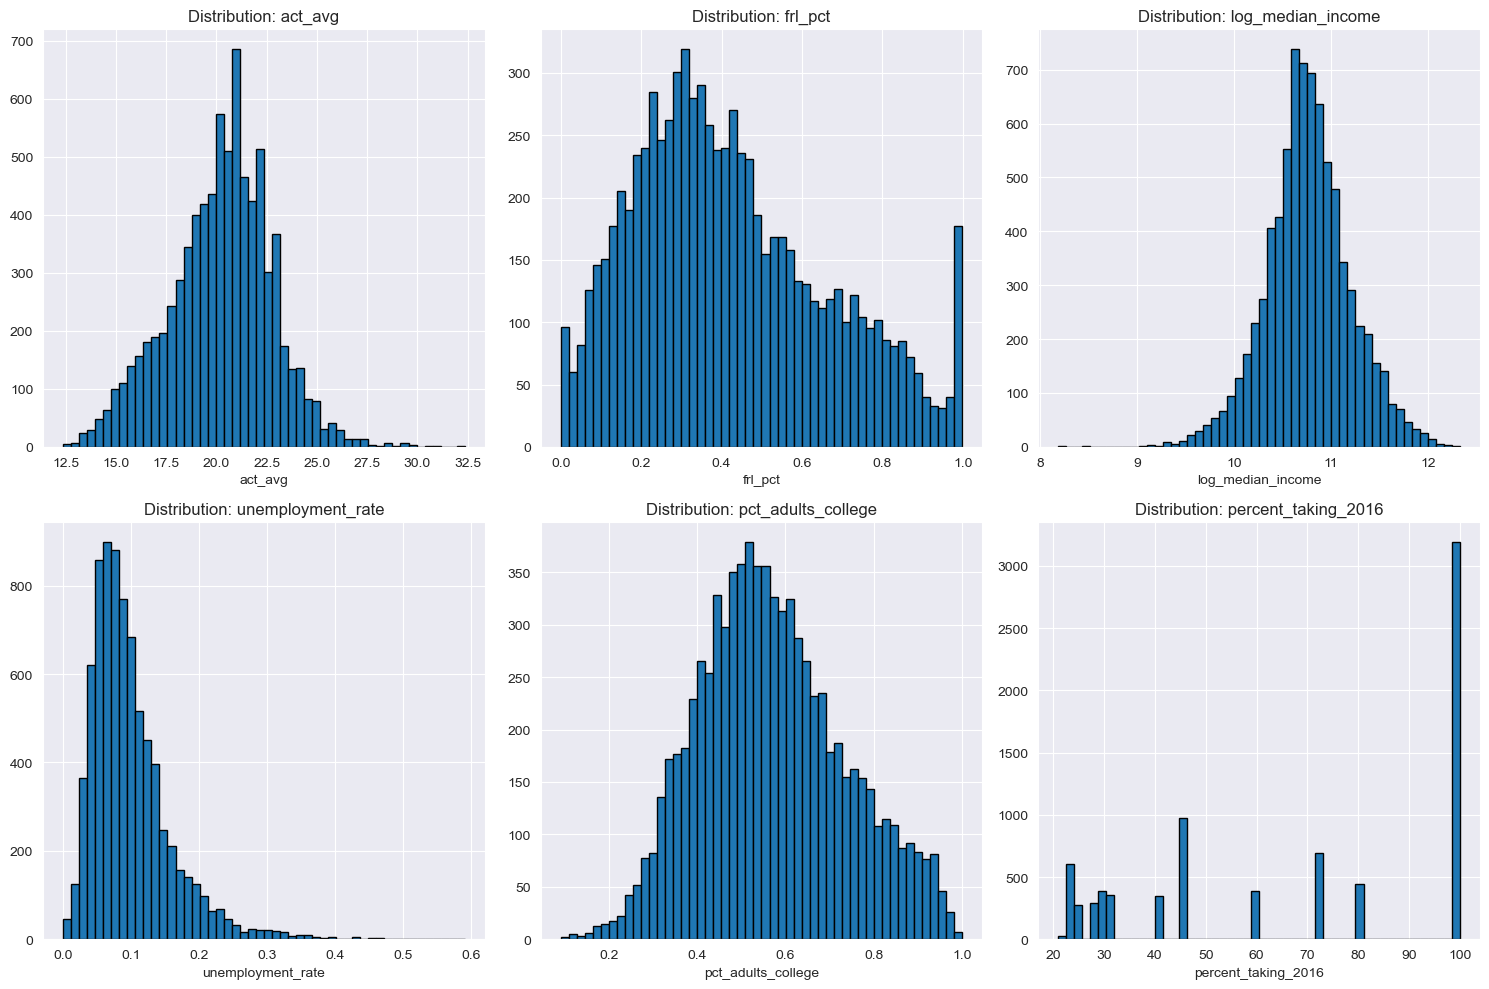


ACT Scores by Region:
               count   mean  median   std    min    max
census_region                                          
Midwest         2996  20.46   20.70  2.37  12.50  29.60
Northeast       1637  20.18   20.74  3.17  12.36  32.36
South           3038  19.83   19.84  2.34  12.70  30.95
West             312  21.21   21.37  2.17  14.85  26.77
Missing Data Summary:
                             missing_count  missing_pct
pct_children_married_couple             25     0.313165
frl_pct                                 20     0.250532
log_median_income                       20     0.250532
unemployment_rate                       14     0.175373
pct_adults_college                      13     0.162846
act_avg                                  0     0.000000
percent_taking_2016                      0     0.000000

Complete cases: 7938 / 7983 (99.4%)

✓ Data quality is excellent - minimal missing data (<5% in all variables)
  No missing data pattern visualization needed.


<Figure size 1000x600 with 0 Axes>

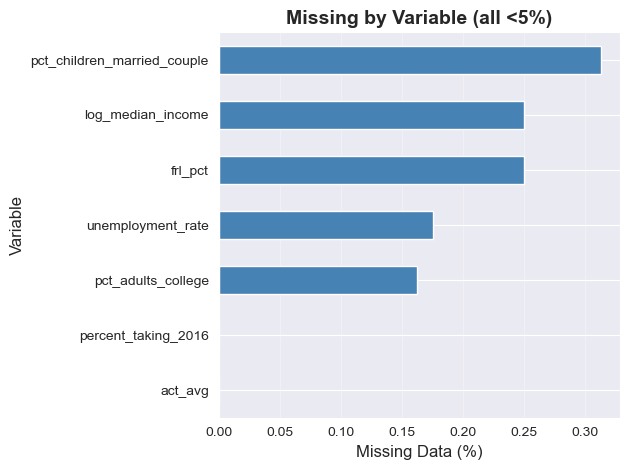


=== Regional Analysis: Statistical Tests ===

One-Way ANOVA Test:
  F-statistic: 49.257
  p-value: 0.0000
  → Significant regional differences detected (p < 0.05)

Pairwise t-tests (Bonferroni correction applied):
  South vs Midwest: mean diff = -0.63, p = 0.0000 *
  South vs Northeast: mean diff = -0.35, p = 0.0000 *
  South vs West: mean diff = -1.39, p = 0.0000 *
  Midwest vs Northeast: mean diff = 0.28, p = 0.0006 *
  Midwest vs West: mean diff = -0.75, p = 0.0000 *
  Northeast vs West: mean diff = -1.03, p = 0.0000 *

Results saved to: ../reports/regional_anova_results.csv


In [195]:

import seaborn as sns

# FRL vs ACT - SEABORN VERSION
plt.figure(figsize=(10, 6))
# plt.scatter(df['frl_pct'], df['act_avg'], alpha=0.5)  # Initial attempt - too cluttered and caused the plots to be "blurry"
sns.regplot(data=df, x="frl_pct", y="act_avg",
            scatter_kws={'alpha':0.1, 's':5, 'color':'steelblue'},
            line_kws={'color':'red', 'linewidth':2.5})
plt.xlabel("FRL % (0–1)", fontsize=12)
plt.ylabel("ACT Average", fontsize=12)
plt.title("FRL vs ACT Average (school-level)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "frl_vs_act.png", dpi=300)
plt.show()

# Income vs ACT - SEABORN VERSION
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="log_median_income", y="act_avg",
            scatter_kws={'alpha':0.1, 's':5, 'color':'darkgreen'},
            line_kws={'color':'darkblue', 'linewidth':2.5})
plt.xlabel("log(Median Household Income)", fontsize=12)
plt.ylabel("ACT Average", fontsize=12)
plt.title("Income (log) vs ACT Average", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "income_log_vs_act.png", dpi=300)
plt.show()

# Region boxplot
order = df.groupby("census_region")["act_avg"].median().sort_values(ascending=False).index.tolist()
groups = [df.loc[df["census_region"]==reg, "act_avg"].dropna().values for reg in order if len(df.loc[df["census_region"]==reg, "act_avg"].dropna())>0]
labels = [reg for reg in order if len(df.loc[df["census_region"]==reg, "act_avg"].dropna())>0]

if groups:
    plt.figure()
    plt.boxplot(groups, labels=labels, vert=True, showmeans=True)
    plt.ylabel("ACT Average")
    plt.title("ACT Average by Census Region")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(REPORTS / "act_by_region_boxplot.png")
    plt.show()

## 5.2) Summary Statistics
summary_stats = df[['act_avg', 'frl_pct', 'median_household_income',
                     'unemployment_rate', 'pct_adults_college']].describe()
summary_stats.to_csv(REPORTS / "descriptive_statistics.csv")
print(summary_stats)

## 5.3) Correlation Matrix
import seaborn as sns

corr_vars = ['act_avg', 'frl_pct', 'log_median_income', 'unemployment_rate',
             'pct_adults_college', 'pct_children_married_couple', 'percent_taking_2016']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True)
plt.title('Correlation Matrix: ACT and Socioeconomic Variables')
plt.tight_layout()
plt.savefig(REPORTS / 'correlation_heatmap.png', dpi=300)
plt.show()

## 5.4) Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(['act_avg', 'frl_pct', 'log_median_income',
                          'unemployment_rate', 'pct_adults_college', 'percent_taking_2016']):
    df[col].hist(bins=50, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.savefig(REPORTS / 'distributions.png', dpi=300)
plt.show()

## 5.5) Regional Summary
regional_summary = df.groupby('census_region')['act_avg'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print("\nACT Scores by Region:")
print(regional_summary)
regional_summary.to_csv(REPORTS / 'regional_summary.csv')

## 5.6) Missing Data Analysis

# Define the features we'll analyze
analysis_vars = ['act_avg', 'frl_pct', 'log_median_income', 'unemployment_rate',
                 'pct_adults_college', 'pct_children_married_couple', 'percent_taking_2016']

# Show missingness by column
missing_summary = pd.DataFrame({
    'missing_count': df[analysis_vars].isna().sum(),
    'missing_pct': df[analysis_vars].isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

print("Missing Data Summary:")
print(missing_summary)

# Show how many complete cases you have
complete_cases = df[analysis_vars].notna().all(axis=1).sum()
complete_pct = 100*complete_cases/len(df)
print(f"\nComplete cases: {complete_cases} / {len(df)} ({complete_pct:.1f}%)")

# Only create heatmap if there's meaningful missingness (>5%)
if missing_summary['missing_pct'].max() > 5:
    # Visualize missingness pattern
    import seaborn as sns
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[analysis_vars].isna(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Data Pattern')
    plt.tight_layout()
    plt.savefig(REPORTS / 'missing_data_heatmap.png', dpi=300)
    plt.show()
else:
    print("\n✓ Data quality is excellent - minimal missing data (<5% in all variables)")
    print("  No missing data pattern visualization needed.")

    # Create a simple bar chart instead
    plt.figure(figsize=(10, 6))
    missing_summary.sort_values('missing_pct', ascending=True).plot(
        kind='barh', y='missing_pct', legend=False, color='steelblue'
    )
    plt.xlabel('Missing Data (%)', fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.title('Missing by Variable (all <5%)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(REPORTS / 'missing_data_summary.png', dpi=300)
    plt.show()

## 5.7) Statistical Testing for Regional Differences

from scipy.stats import f_oneway, ttest_ind

print("\n=== Regional Analysis: Statistical Tests ===\n")

# Test if regional differences in ACT scores are statistically significant
regions_data = []
region_names = []

for region in df['census_region'].dropna().unique():
    region_scores = df[df['census_region'] == region]['act_avg'].dropna().values
    if len(region_scores) > 0:
        regions_data.append(region_scores)
        region_names.append(region)

# ANOVA test
if len(regions_data) >= 2:
    f_stat, p_value = f_oneway(*regions_data)
    print(f"One-Way ANOVA Test:")
    print(f"  F-statistic: {f_stat:.3f}")
    print(f"  p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("  → Significant regional differences detected (p < 0.05)\n")

        # Post-hoc pairwise comparisons (only if ANOVA is significant)
        print("Pairwise t-tests (Bonferroni correction applied):")
        from itertools import combinations
        n_comparisons = len(list(combinations(range(len(region_names)), 2)))
        alpha_corrected = 0.05 / n_comparisons  # Bonferroni correction

        significant_pairs = []
        for i, j in combinations(range(len(region_names)), 2):
            t, p = ttest_ind(regions_data[i], regions_data[j])
            if p < alpha_corrected:
                mean_diff = regions_data[i].mean() - regions_data[j].mean()
                significant_pairs.append((region_names[i], region_names[j], mean_diff, p))
                print(f"  {region_names[i]} vs {region_names[j]}: "
                      f"mean diff = {mean_diff:.2f}, p = {p:.4f} *")

        if not significant_pairs:
            print("  No pairwise differences significant after Bonferroni correction")
    else:
        print("  → No significant regional differences (p >= 0.05)")
else:
    print("Not enough regions for ANOVA test")

# Save results
anova_results = pd.DataFrame({
    'test': ['ANOVA'],
    'statistic': [f_stat],
    'p_value': [p_value],
    'significant': [p_value < 0.05]
})
anova_results.to_csv(REPORTS / 'regional_anova_results.csv', index=False)
print(f"\nResults saved to: {REPORTS / 'regional_anova_results.csv'}")

## 6) Baseline model

{'R2': 0.614, 'MAE': 1.183, 'n_train': 6350, 'n_test': 1588}


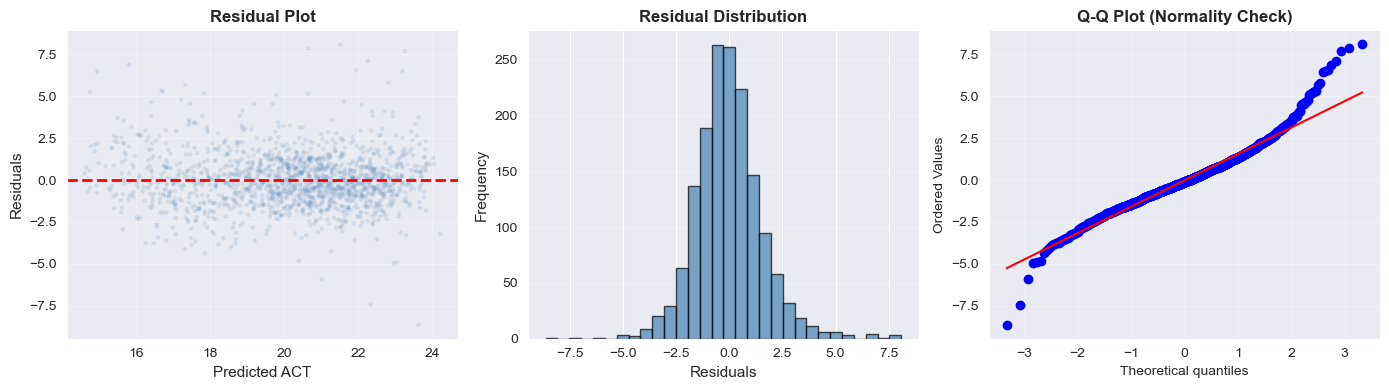


Variance Inflation Factors:
                      Variable        VIF
1            log_median_income  70.335548
4  pct_children_married_couple  22.120869
3           pct_adults_college  20.050626
0                      frl_pct   6.243792
2            unemployment_rate   6.051818
5          percent_taking_2016   5.841432

(VIF > 10 suggests problematic multicollinearity)


In [196]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

features = [c for c in ["frl_pct","log_median_income","unemployment_rate","pct_adults_college","pct_children_married_couple","percent_taking_2016"] if c in df.columns]
X = df[features].select_dtypes(include=[np.number]).copy()
y = df["act_avg"].copy()

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]; y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
coefs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print({"R2": round(r2,3), "MAE": round(mae,3), "n_train": len(X_train), "n_test": len(X_test)})
coefs.to_frame("coefficient")

## 6.5) Model Diagnostics

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
# FIX: Reduce alpha and point size for clarity
plt.scatter(y_pred, residuals, alpha=0.15, s=10, color='steelblue', edgecolors='none')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted ACT', fontsize=11)
plt.ylabel('Residuals', fontsize=11)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(residuals, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
plt.xlabel('Residuals', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Residual Distribution', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS / 'model_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Check for multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors:")
print(vif_data.sort_values('VIF', ascending=False))
print("\n(VIF > 10 suggests problematic multicollinearity)")


In [197]:
## 6.6) Generate Interpretation

# Calculate interpretation values
r2_pct = round(r2 * 100, 1)
mae_rounded = round(mae, 1)

# Get coefficients
frl_coef = coefs['frl_pct']
income_coef = coefs['log_median_income']
college_coef = coefs['pct_adults_college']
participation_coef = coefs['percent_taking_2016']

# Calculate practical effects
frl_effect_per_10pct = abs(frl_coef * 0.1)  # 10 percentage point change
income_effect_per_10pct = income_coef * np.log(1.10)  # 10% increase (log scale)
college_effect_per_10pct = college_coef * 0.1  # 10 percentage point change

# Check VIF
max_vif = vif_data['VIF'].max()

# Residuals interpretation
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Sample if too large
is_normal = "approximately normal" if shapiro_p > 0.05 else "slight deviation from normality"

print("=== INTERPRETATION VALUES ===\n")
print(f"Model R2: {r2_pct}%")
print(f"Model explains {r2_pct}% of variance in ACT scores\n")

print(f"FRL Impact: {frl_effect_per_10pct:.1f} point decrease per 10% increase")
print(f"Income Effect: {income_effect_per_10pct:.2f} point increase per 10% income increase")
print(f"Education Effect: {college_effect_per_10pct:.2f} point increase per 10% more college-educated adults")
print(f"Participation Effect: coefficient = {participation_coef:.2f}\n")

print(f"MAE: {mae_rounded} points (predictions typically accurate within +-{mae_rounded} points)")
print(f"Max VIF: {max_vif:.1f} ({'< 5, no multicollinearity concern' if max_vif < 5 else 'check for multicollinearity'})")
print(f"Residuals: {is_normal}")

=== INTERPRETATION VALUES ===

Model R2: 61.4%
Model explains 61.4% of variance in ACT scores

FRL Impact: 0.8 point decrease per 10% increase
Income Effect: -0.07 point increase per 10% income increase
Education Effect: 0.22 point increase per 10% more college-educated adults
Participation Effect: coefficient = -0.01

MAE: 1.2 points (predictions typically accurate within +-1.2 points)
Max VIF: 70.3 (check for multicollinearity)
Residuals: slight deviation from normality


## 7) Save report tables

In [198]:

summary = pd.DataFrame({"metric":["R2","MAE","n_train","n_test"], "value":[round(r2,3), round(mae,3), len(X_train), len(X_test)]})
summary.to_csv(REPORTS / "model_summary.csv", index=False)
coefs.to_csv(REPORTS / "model_coefficients.csv", header=["coefficient"])
(str(REPORTS / "model_summary.csv"), str(REPORTS / "model_coefficients.csv"))


('../reports/model_summary.csv', '../reports/model_coefficients.csv')


## 8) Conclusions

- **Directionality:** FRL% shows a strong negative association with ACT averages; higher FRL% → lower ACT.  
- **Context:** Income and adult education correlate positively with ACT, unemployment negatively.  
- **Selection effect:** State ACT participation rate (2016) is a modest negative coefficient—consistent with states where more students take the ACT tending to show lower averages (selection vs census testing).  
- **Next steps:** Robustness checks (regularization, interaction terms), sensitivity to alternative scales, and potential school-level fixed effects if district IDs become available.



## 9) State-level analysis

We aggregate school-level data to state-level to compare socioeconomic indicators with state ACT composite (2016) and participation.


In [199]:

# --- Build state-level table ---
import pandas as pd, numpy as np

# --- Build state-level table ---
# (df already exists from previous sections)

state_agg = (df.groupby(["state_abbrev","state_name","census_region","census_division"], dropna=False)
    .agg(
        act_avg_school_mean = ("act_avg","mean"),
        frl_pct_mean = ("frl_pct","mean"),
        median_household_income_mean = ("median_household_income","mean"),
        unemployment_rate_mean = ("unemployment_rate","mean"),
        pct_adults_college_mean = ("pct_adults_college","mean"),
        pct_children_married_couple_mean = ("pct_children_married_couple","mean")
    )
    .reset_index()
)

# Merge state ACT composite + participation
act = df[["state_abbrev","act_composite_2016","percent_taking_2016"]].dropna(subset=["state_abbrev"]).drop_duplicates("state_abbrev")
state_agg = state_agg.merge(act, on="state_abbrev", how="left")

# Derive log income (from mean income)
state_agg["log_median_income_mean"] = np.log(state_agg["median_household_income_mean"].replace({0: np.nan}))

print(f"State-level aggregation complete: {len(state_agg)} states")
state_agg.sort_values("state_abbrev").head(8)

State-level aggregation complete: 20 states


,state_abbrev,state_name,census_region,census_division,act_avg_school_mean,frl_pct_mean,median_household_income_mean,unemployment_rate_mean,pct_adults_college_mean,pct_children_married_couple_mean,act_composite_2016,percent_taking_2016,log_median_income_mean
0,DE,Delaware,South,South Atlantic,17.418428,0.313367,64856.730769,0.078371,0.603379,0.647402,23.6,21,11.079936
1,FL,Florida,South,South Atlantic,20.343888,0.437750,48163.396789,0.118232,0.566971,0.581553,19.9,81,10.782355
2,GA,Georgia,South,South Atlantic,19.450128,0.552462,48299.918159,0.119260,0.549618,0.574277,21.1,60,10.785185
3,IL,Illinois,Midwest,East North Central,19.751602,0.422882,55563.131980,0.105147,0.607730,0.651443,20.8,100,10.925275
4,IN,Indiana,Midwest,East North Central,20.594628,0.334738,48272.373219,0.089459,0.526246,0.645716,22.3,41,10.784615
5,KY,Kentucky,South,East South Central,19.196296,0.459198,40415.754630,0.098986,0.511052,0.612950,20.0,100,10.606975
6,LA,Louisiana,South,West South Central,18.990873,0.550005,40333.344000,0.099845,0.460432,0.521357,19.5,100,10.604934
7,MA,Massachusetts,Northeast,New England,21.691003,0.295556,74939.178694,0.087685,0.685542,0.706145,24.8,28,11.224432


### 9.1 Visuals: State-level relationships

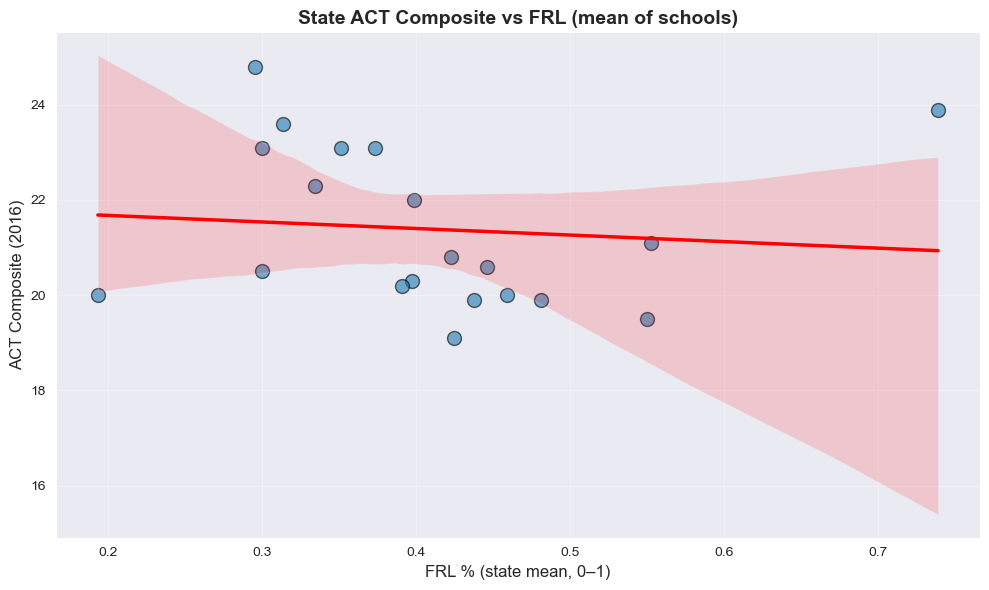

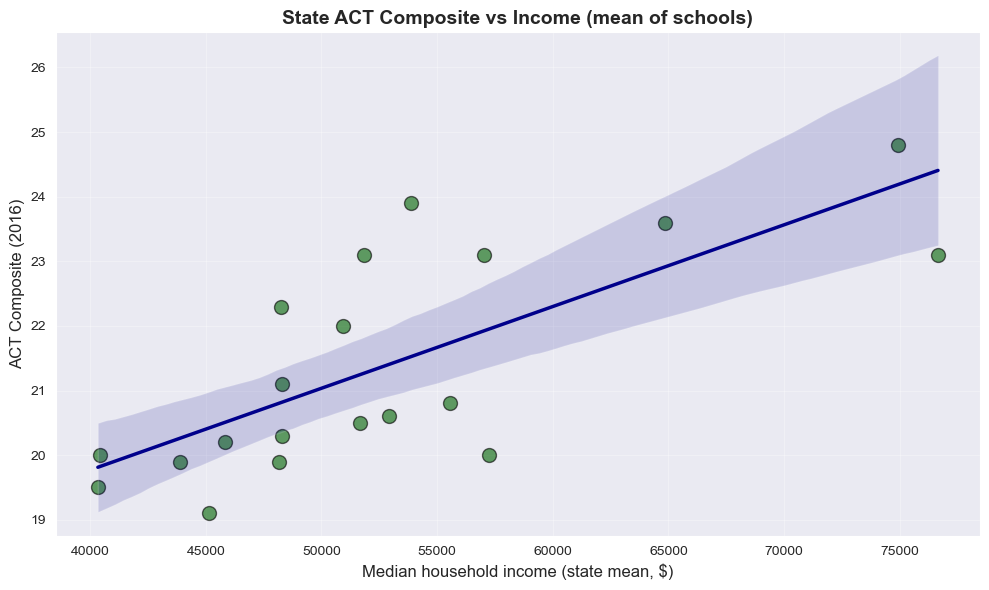

/var/folders/_w/ms1g9gts2bl_shfc5qfpp7x40000gn/T/ipykernel_18887/481719879.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(groups, labels=labels, vert=True, showmeans=True, patch_artist=True,


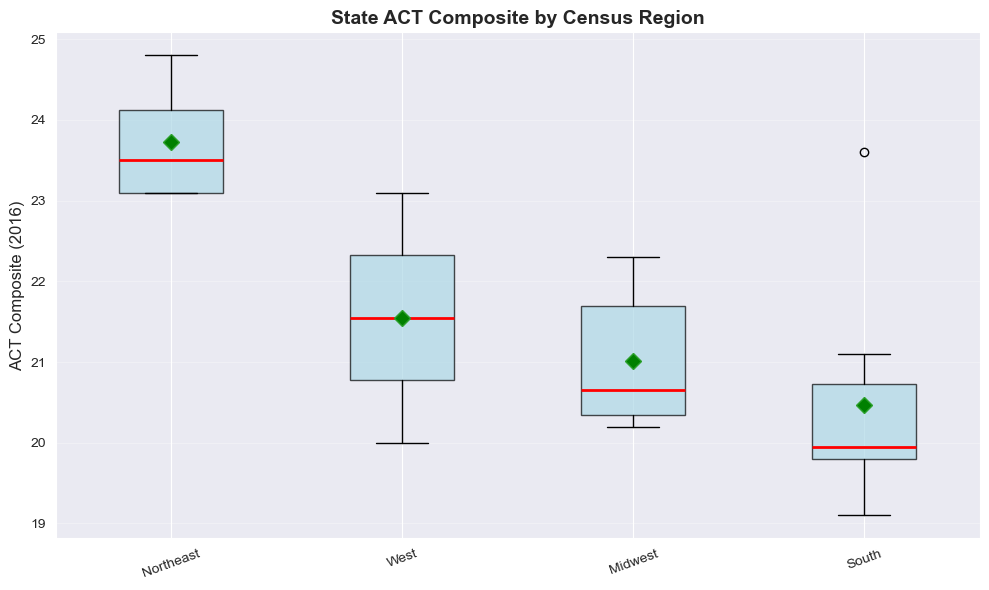

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# FRL vs State ACT composite - SEABORN VERSION
plt.figure(figsize=(10, 6))
sns.regplot(data=state_agg, x="frl_pct_mean", y="act_composite_2016",
            scatter_kws={'s':100, 'alpha':0.6, 'edgecolors':'black', 'linewidths':1},  # ← Changed to linewidths
            line_kws={'color':'red', 'linewidth':2.5})
plt.xlabel("FRL % (state mean, 0–1)", fontsize=12)
plt.ylabel("ACT Composite (2016)", fontsize=12)
plt.title("State ACT Composite vs FRL (mean of schools)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "state_frl_vs_act_composite.png", dpi=300)
plt.show()

# Income vs State ACT composite - SEABORN VERSION
plt.figure(figsize=(10, 6))
sns.regplot(data=state_agg, x="median_household_income_mean", y="act_composite_2016",
            scatter_kws={'s':100, 'alpha':0.6, 'color':'darkgreen', 'edgecolors':'black', 'linewidths':1},  # ← Changed to linewidths
            line_kws={'color':'darkblue', 'linewidth':2.5})
plt.xlabel("Median household income (state mean, $)", fontsize=12)
plt.ylabel("ACT Composite (2016)", fontsize=12)
plt.title("State ACT Composite vs Income (mean of schools)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "state_income_vs_act_composite.png", dpi=300)
plt.show()

# Region boxplot for state ACT - IMPROVED
order = state_agg.groupby("census_region")["act_composite_2016"].median().sort_values(ascending=False).index.tolist()
groups = [state_agg.loc[state_agg["census_region"]==reg, "act_composite_2016"].dropna().values
          for reg in order if len(state_agg.loc[state_agg["census_region"]==reg, "act_composite_2016"].dropna())>0]
labels = [reg for reg in order if len(state_agg.loc[state_agg["census_region"]==reg, "act_composite_2016"].dropna())>0]

if groups:
    plt.figure(figsize=(10, 6))
    bp = plt.boxplot(groups, labels=labels, vert=True, showmeans=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
    plt.ylabel("ACT Composite (2016)", fontsize=12)
    plt.title("State ACT Composite by Census Region", fontsize=14, fontweight='bold')
    plt.xticks(rotation=20)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(REPORTS / "state_act_by_region_boxplot.png", dpi=300)
    plt.show()

### 9.2 State-level regression

In [201]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

features_s = ["frl_pct_mean","log_median_income_mean","unemployment_rate_mean",
              "pct_adults_college_mean","pct_children_married_couple_mean","percent_taking_2016"]
target_s = "act_composite_2016"

state_df = state_agg.dropna(subset=[target_s] + features_s).copy()
X_s = state_df[features_s]
y_s = state_df[target_s]

print(f"State-level analysis with n={len(state_df)} states\n")

# Use cross-validation for small sample size
cv_scores_r2 = cross_val_score(LinearRegression(), X_s, y_s, cv=5, scoring='r2')
cv_scores_mae = cross_val_score(LinearRegression(), X_s, y_s, cv=5,
                                 scoring='neg_mean_absolute_error')

print("5-Fold Cross-Validation Results:")
print(f"  R² = {cv_scores_r2.mean():.3f} (+/- {cv_scores_r2.std():.3f})")
print(f"  MAE = {-cv_scores_mae.mean():.3f} (+/- {cv_scores_mae.std():.3f})")

# Fit on all data for coefficient interpretation
m_s = LinearRegression().fit(X_s, y_s)
coefs_s = pd.Series(m_s.coef_, index=features_s).sort_values(ascending=False)

print("\nCoefficients (fitted on all data for interpretation):")
print(coefs_s.to_frame("coefficient"))

# Also show statsmodels summary for p-values and confidence intervals
import statsmodels.api as sm
X_s_with_const = sm.add_constant(X_s)
sm_model = sm.OLS(y_s, X_s_with_const).fit()
print("\nStatistical Summary:")
print(sm_model.summary())


State-level analysis with n=20 states

5-Fold Cross-Validation Results:
  R² = 0.363 (+/- 0.842)
  MAE = 0.832 (+/- 0.435)

Coefficients (fitted on all data for interpretation):
                                  coefficient
pct_children_married_couple_mean     6.382186
frl_pct_mean                         3.816906
pct_adults_college_mean              2.969713
log_median_income_mean               1.943030
percent_taking_2016                 -0.036069
unemployment_rate_mean              -3.359451

Statistical Summary:
                            OLS Regression Results                            
Dep. Variable:     act_composite_2016   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     14.53
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           4.33e-05
Time:                        13:46:26   Log-Likelihood:                -17.959
No. 

### 9.3 Save state-level summary

In [202]:
out = state_df.assign(predicted=m_s.predict(X_s))
out_path = REPORTS / "state_level_summary.csv"
coef_path = REPORTS / "state_level_coefficients.csv"
out.to_csv(out_path, index=False)
coefs_s.to_csv(coef_path, header=["coefficient"])
print(f"State-level results saved to:")
print(f"  • {out_path}")
print(f"  • {coef_path}")


State-level results saved to:
  • ../reports/state_level_summary.csv
  • ../reports/state_level_coefficients.csv



**Interpretation:**
- FRL (state mean) typically shows a negative association with state ACT composite.
- Adult college attainment and income (state means) show positive associations.
- Participation rate is often negatively associated with composite scores due to selection effects.



## 10) Reflection & Challenges

**Challenges Encountered:**
- **Data Set Issuse**: For whatever reason the data used did not have a CHARTER column as used during the video discussions. This caused a lot of frustration when following along in class. At this point, I am assuming that there was some difference that was overlooked by myself or something else. I ignored anything related to CHARTER and what we covered in the class.
- **NCES Join Issue**: The NCESSCH IDs did not match between datasets, requiring a fallback to state-level enrichment. This taught me the importance of always inspecting join results.
- **Data Cleaning Decisions**: Initially only detected invalid ACT scores but didn't remove them. Realized during EDA that these needed to be cleaned before analysis.
- **Small Sample Size for State-Level**: With only ~50 states, the state-level analysis required cross-validation to avoid overfitting.

**What I Learned:**
- How to handle imperfect data joins gracefully
- The importance of both detection AND correction in data cleaning
- When to use ANOVA for group comparisons
- How multicollinearity affects regression (VIF analysis)
- Cross-validation is crucial for small samples